## Get started
This tutorial will show you how asynctorch can be used. Make sure asynctorch, snnTorch and tonic have been installed! Tonic is not an automatic dependency of asynctorch because it is not required for all use cases. For CUDA support, make sure you have a working CUDA installation and the correct version of PyTorch installed.

Check our paper for more details: https://arxiv.org/abs/2408.05098

### Import packages

In [11]:
import torch
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms
from asynctorch.simulator.async_simulator import AsyncSimulator
from asynctorch.nn.architecture.mixed_architecture import MixedArchitecture, AsyncNetwork
from asynctorch.nn.neuron.lif_state import LIFState
from asynctorch.simulator.extensions.spike_dropout_extension import SpikeDropoutExtension
from asynctorch.simulator.spike_scheduler import RandomSpikeScheduler
from asynctorch.simulator.spike_scheduler import MomentumSpikeScheduler
from asynctorch.simulator.spike_selector import SpikeSelector
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import snntorch.functional as SF
from asynctorch.utils.surrogate import ATan
from math import prod
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Load data
For this, tonic is used. This can take same time when it is run for the first time.

In [12]:
# Data loading — replace the tonic N-MNIST cells with:
import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])  # flatten to 784
train_dataset = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)
collate_fn = None  # no padding needed, all samples same size

### Define the network and parameters for simulator
We provide two network architectures. An architecture consists of just the connecting layer, so not the (spiking) activations / neurons. You can use the layers from PyTorch, like nn.Conv2d and nn.Linear. On top of that, you must also provide their input shape. 
In a later cell, these definitions will be used to construct the network. We assume here that you want a fully sequential network. For more advanced structures like residual connections, you must manually connect each layer to neurons. This will be discussed in another tutorial (to be added later). For now, after running "CNN" or "Linear", just run the "Build" cell to construct.

#### CNN

In [ ]:
n_outputs = 10
input_shape = (2, 34, 34) # Shape of the input data
layer1_shape = (8, 16, 16)
layer2_shape = (16, 8, 8)
layer3_shape = (32, 4, 4)
module_per_layer = [nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=0, bias=False), 
                    nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1, bias=False), 
                    nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False),
                    nn.Linear(prod(layer3_shape), n_outputs, bias=False)]
shape_per_layer = [input_shape, layer1_shape, layer2_shape, (prod(layer3_shape), ), (n_outputs, )]
neurons_per_layer = [prod(shape) for shape in shape_per_layer[1:]]
n_neurons = sum(neurons_per_layer)

#### Linear

In [13]:
# Network — use the Linear cell with MNIST sizes:
n_outputs    = 10
input_shape  = (784,)      # 28*28
layer1_shape = (128,)
# layer_sizes = [784, 128, 10]  ← matches Laurent's config

module_per_layer = [
    nn.Linear(784, 128, bias=False),
    nn.Linear(128, 10,  bias=False)
]
shape_per_layer = [(784,), (128,), (10,)]
neurons_per_layer = [128, 10]
n_neurons = 138

#### Build
The building process consists of first taking the network definitions from the previous cells and then using those to construct an architecture module. This will provide the logic for how to forward spikes and currents. How the neurons behave is defined in a state module, in this case LIF neurons are used. The last step is defining how spikes are selected and then combining everything into the simulator environment. Optionally, "extensions" can be provided. In this example, spike dropout will be used for regularization, but only applied to the input. Different from torch dropout, it is not directly included in the architecture, but rather added as an extension.

In [4]:
# Network architecture
async_network = AsyncNetwork.build_sequential(module_per_layer, shape_per_layer).to(device)
print(async_network)
print('Number of neurons:', n_neurons)
print('Number of parameters:', sum(p.numel() for p in async_network.parameters() if p.requires_grad))
network_module = MixedArchitecture(async_network, device)

# Neuron model
spike_grad = ATan()
state_module = LIFState(
    neurons_per_layer,
    tau_m=1000,
    membrane_threshold=0.3,
    spike_grad=spike_grad,
    device=device,
    refrac_dropout=0.8, # Probability that a neuron can spike again in the same forward pass during training, check paper for more details
)

# Spike selection
spike_scheduler = RandomSpikeScheduler(state_module)
spike_selector_module = SpikeSelector(
    network_module,
    spike_scheduler,
    forward_group_size=128, # How many spikes are processed in parallel per forward step
    device=device,
    prioritize_input=True,
    log_queue_length=True
)
# Simulator and extensions
input_dropout = SpikeDropoutExtension(p=0.25, apply_to_input=True, apply_to_network=False)
async_simulator = AsyncSimulator(state_module, spike_selector_module, forward_step_extensions=[input_dropout])

AsyncNetwork(
  (input_layer): AsyncLayer(
    (module): Linear(in_features=784, out_features=128, bias=False)
  )
  (layers): ModuleList(
    (0): AsyncLayer(
      (module): Linear(in_features=128, out_features=10, bias=False)
    )
  )
)
Number of neurons: 138
Number of parameters: 101632


In [15]:
# Network
async_network = AsyncNetwork.build_sequential(module_per_layer, shape_per_layer).to(device)
network_module = MixedArchitecture(async_network, device)

# Neuron model — paper params: tau_m=1ms, threshold=0.3, refrac_dropout=0.8
spike_grad = ATan()
state_module = LIFState(
    neurons_per_layer,
    tau_m=1000,              # 1000 steps ≈ 1ms for MNIST (one step per pixel)
    membrane_threshold=0.3,  # U_thr from Table 6
    spike_grad=spike_grad,
    device=device,
    refrac_dropout=0.8,      # refractory dropout from Table 6
)

# ← THE KEY CHANGE: MomentumSpikeScheduler instead of Random

spike_scheduler = MomentumSpikeScheduler(state_module, lambda_=1e-6)

spike_selector_module = SpikeSelector(
    network_module,
    spike_scheduler,
    forward_group_size=8,    # F=8 from Table 6 for N-MNIST
    device=device,
    prioritize_input=True,
    log_queue_length=True
)

input_dropout = SpikeDropoutExtension(p=0.25, apply_to_input=True, apply_to_network=False)
async_simulator = AsyncSimulator(state_module, spike_selector_module,
                                  forward_step_extensions=[input_dropout])

## Start training
For training, we use the standard PyTorch training loop with some snnTorch specific functions. Instead of calling a forward pass on the network, we call the forward function of the simulator. This function takes the input data and the time step, and returns the output spikes of the network. The output spikes can then be used to calculate the loss and update the weights of the network.

In [16]:
# MNIST is a static dataset — no time dimension, so no timestep loop
# dt=1.0 is a dummy value; for static input asynctorch just needs a positive float

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
async_simulator.train()
n_epochs = 20
optimizer = torch.optim.Adam(async_simulator.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate
losses = []
accuracies = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    epoch_acc  = 0.0
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter, desc=f"Epoch {epoch+1}/{n_epochs}"):
        data    = data.to(device)     # shape: [batch, 784]  (already flattened by transform)
        targets = targets.to(device)
        async_simulator.reset_state()

        # MNIST has no time steps — feed the whole image as one forward pass
        # unsqueeze(0) adds a fake time dimension of 1 so the loss fn shape is [T, B, C]
        spk_out = async_simulator(data, dt=1.0)[:, n_neurons - n_outputs:]  # [batch, 10]
        y = spk_out.unsqueeze(0)  # [1, batch, 10]  ← shape expected by ce_rate_loss

        loss = loss_fn(y, targets)
        acc  = accuracy_function(y, targets)
        losses.append(loss.item())
        accuracies.append(acc)
        epoch_loss += loss.item()
        epoch_acc  += acc

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    n_batches = len(train_dataloader)
    print(f"Epoch {epoch+1:2d} | loss={epoch_loss/n_batches:.4f}  acc={epoch_acc/n_batches:.4f}")


Epoch 1/20: 100%|██████████| 235/235 [00:13<00:00, 17.69it/s]


Epoch  1 | loss=1.1616  acc=0.7453


Epoch 2/20: 100%|██████████| 235/235 [00:12<00:00, 18.49it/s]


Epoch  2 | loss=0.9721  acc=0.7704


Epoch 3/20: 100%|██████████| 235/235 [00:12<00:00, 18.82it/s]


...

Epoch 18 | loss=0.7203  acc=0.8672


Epoch 19/20: 100%|██████████| 235/235 [00:12<00:00, 19.41it/s]


Epoch 19 | loss=0.7204  acc=0.8670


Epoch 20/20: 100%|██████████| 235/235 [00:13<00:00, 17.74it/s]

Epoch 20 | loss=0.7160  acc=0.8728


save

In [17]:
import os
os.makedirs("weight", exist_ok=True)
torch.save(async_network.state_dict(), "weight/asynctorch_mnist_linear.pt")
print("Weights saved!")

Weights saved!


### Plot the training progress

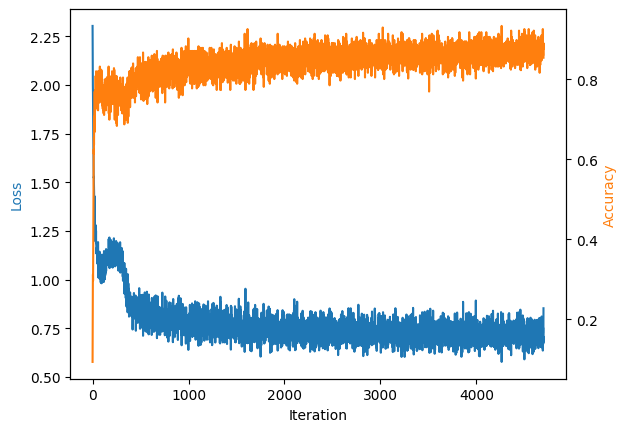

In [18]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(losses, color='C0')
ax2.plot(accuracies, color='C1')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='C0')
ax2.set_ylabel('Accuracy', color='C1')

plt.show()

## Test the model

In [19]:
async_simulator.eval()
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn)
correct = 0
total   = 0

with torch.inference_mode():
    for data, targets in tqdm(test_dataloader):
        data    = data.float().to(device)   # [batch, 784]
        targets = targets.to(device)
        async_simulator.reset_state()

        spk_out = async_simulator(data, dt=1.0)[:, n_neurons - n_outputs:]  # [batch, 10]
        predictions = torch.argmax(spk_out, dim=1)
        correct += predictions.eq(targets).sum().item()
        total   += targets.size(0)

print(f"Test accuracy: {correct/total:.4f}  ({correct}/{total})")


100%|██████████| 79/79 [00:03<00:00, 20.08it/s]

Test accuracy: 0.8719  (8719/10000)
